# Paper-fit versions of the 20d/10n OOD log marginal likelihood diagnostics

This notebook uses the saved results from `ood_analysis_l2_20d_10n.ipynb` and draws a few more compact versions of the wide 4 x 12 diagnostic plot.

The goal is only visual comparison for the thesis layout. It does not modify `summry_diagnostic.py` or regenerate simulation results.


In [1]:
%matplotlib inline

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "notebooks":
    NOTEBOOK_DIR = Path("/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/notebooks")

GAUSSIAN_DIR = NOTEBOOK_DIR.parent
RESULT_DIR = GAUSSIAN_DIR / "results" / "ood_20d_10n"
FIGURE_DIR = GAUSSIAN_DIR / "figures" / "ood_20d_10n_paper_fit"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_MODELS = tuple(f"m{i}" for i in range(1, 13))
ASSUMED_MODELS = tuple(f"m{i}" for i in range(1, 5))

ERROR_BOUND = 100.0
REPRESENTATIVE_SOURCES = ("m1", "m2", "m7", "m8")

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 120,
})


In [2]:
logml_df = pd.read_csv(RESULT_DIR / "logml_distance_frame_20d_10n.csv")

logml_df["source_model"] = pd.Categorical(logml_df["source_model"], SOURCE_MODELS, ordered=True)
logml_df["assumed_model"] = pd.Categorical(logml_df["assumed_model"], ASSUMED_MODELS, ordered=True)
logml_df["abs_logml_error"] = logml_df["signed_logml_error"].abs()

print(logml_df.shape)
logml_df.head()


(2400, 12)


,source_model,source_index,id,assumed_model,d_M,dm_low,dm_high,distance_regime,gold_logml,npe_logml,signed_logml_error,abs_logml_error
0,m1,0,0,m1,1.106424,0.688525,1.307121,in_distribution,-329.171074,-329.180350,-0.009276,0.009276
1,m1,0,0,m2,2.084169,0.682469,1.324885,extrapolation,-420.543267,-589.560642,-169.017375,169.017375
2,m1,0,0,m3,1.449616,0.742208,1.195115,extrapolation,-430.114321,-430.464044,-0.349723,0.349723
3,m1,0,0,m4,0.922187,0.680943,1.326334,in_distribution,-329.580450,-329.580146,0.000304,0.000304
4,m1,0,1,m1,1.103923,0.688525,1.307121,in_distribution,-300.431259,-300.447966,-0.016707,0.016707


In [3]:
REGIME_COLORS = {
    "interpolation": "#f0b429",
    "in_distribution": "#74add1",
    "extrapolation": "#e78ac3",
}


def source_label(model):
    return model.upper()


def add_distance_regions(ax, low, high, x_min, x_max):
    ax.axvspan(x_min, low, color=REGIME_COLORS["interpolation"], alpha=0.08)
    ax.axvspan(low, high, color=REGIME_COLORS["in_distribution"], alpha=0.07)
    ax.axvspan(high, x_max, color=REGIME_COLORS["extrapolation"], alpha=0.07)
    ax.axvline(low, color=REGIME_COLORS["interpolation"], linestyle="--", linewidth=0.9)
    ax.axvline(high, color=REGIME_COLORS["extrapolation"], linestyle="--", linewidth=0.9)


def add_first_large_error(ax, sub, x_col, error_bound=ERROR_BOUND):
    hit = (
        sub.loc[sub["signed_logml_error"].abs() > error_bound, [x_col, "signed_logml_error"]]
        .dropna()
        .sort_values(x_col)
        .head(1)
    )
    if hit.empty:
        return
    x0 = float(hit[x_col].iloc[0])
    ax.axvline(x0, color="0.2", linestyle=":", linewidth=1.0)
    ax.text(x0, 0.96, f"{x0:.2g}", transform=ax.get_xaxis_transform(), ha="right", va="top", rotation=90, fontsize=9)


def style_grid(axes):
    for ax in np.asarray(axes).ravel():
        ax.axhline(0, color="0.35", linewidth=0.7)
        ax.grid(alpha=0.16)
        ax.tick_params(length=3)


def plot_logml_scatter_grid(
    df,
    sources,
    title,
    filename,
    x_min=0.0,
    y_limits=None,
    error_bound=ERROR_BOUND,
):
    fig, axes = plt.subplots(
        len(ASSUMED_MODELS),
        len(sources),
        figsize=(2.35 * len(sources), 7.6),
        sharey=True,
        squeeze=False,
    )

    for r, assumed in enumerate(ASSUMED_MODELS):
        for c, source in enumerate(sources):
            ax = axes[r, c]
            sub = df[(df["assumed_model"] == assumed) & (df["source_model"] == source)].copy()
            if sub.empty:
                ax.set_axis_off()
                continue

            low = float(sub["dm_low"].iloc[0])
            high = float(sub["dm_high"].iloc[0])
            x_max = max(float(sub["d_M"].max()) * 1.05, high * 1.15)
            add_distance_regions(ax, low, high, x_min, x_max)

            ax.scatter(sub["d_M"], sub["signed_logml_error"], s=13, color="0.12", alpha=0.62, linewidths=0)
            add_first_large_error(ax, sub, "d_M", error_bound)
            ax.set_xlim(x_min, x_max)

            if r == 0:
                ax.set_title(source_label(source))
            if c == 0:
                ax.set_ylabel(f"Assumed {assumed.upper()}")

    if y_limits is not None:
        for ax in axes.ravel():
            ax.set_ylim(*y_limits)

    style_grid(axes)
    fig.supxlabel(r"$d_j(y)$", y=0.03)
    fig.supylabel(r"$\hat{p}(y\mid M_j)-p(y\mid M_j)$", x=0.015)
    fig.suptitle(title, y=0.995)
    fig.tight_layout(rect=(0.025, 0.035, 1, 0.965))
    fig.savefig(FIGURE_DIR / filename, dpi=220, bbox_inches="tight")
    return fig, axes


def plot_logml_error_heatmaps(df, filename="logml_error_heatmap_compact.png"):
    summary = (
        df.groupby(["assumed_model", "source_model"], observed=True)
        .agg(
            median_abs_error=("abs_logml_error", "median"),
            q95_abs_error=("abs_logml_error", lambda x: np.quantile(x, 0.95)),
            frac_large_error=("abs_logml_error", lambda x: np.mean(x > ERROR_BOUND)),
        )
        .reset_index()
    )

    fig, axes = plt.subplots(1, 3, figsize=(12.6, 3.2), constrained_layout=True)
    specs = [
        ("median_abs_error", r"$\log_{10}(1+\mathrm{median}\ |error|)$"),
        ("q95_abs_error", r"$\log_{10}(1+q_{0.95}\ |error|)$"),
        ("frac_large_error", rf"$\Pr(|error|>{ERROR_BOUND:g})$"),
    ]

    for ax, (value, label) in zip(axes, specs):
        mat = (
            summary.pivot(index="assumed_model", columns="source_model", values=value)
            .loc[list(ASSUMED_MODELS), list(SOURCE_MODELS)]
            .astype(float)
        )
        shown = np.log10(1.0 + mat) if value != "frac_large_error" else mat
        im = ax.imshow(shown, aspect="auto", cmap="magma")
        ax.set_xticks(range(len(SOURCE_MODELS)))
        ax.set_xticklabels([m.upper() for m in SOURCE_MODELS], rotation=45, ha="right")
        ax.set_yticks(range(len(ASSUMED_MODELS)))
        ax.set_yticklabels([m.upper() for m in ASSUMED_MODELS])
        ax.set_xlabel("Source model")
        ax.set_ylabel("Assumed model")
        ax.set_title(label)
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.025)
        cbar.ax.tick_params(labelsize=9)

    fig.savefig(FIGURE_DIR / filename, dpi=220, bbox_inches="tight")
    return fig, axes, summary


## Option 1: compact heatmap summary

This is the most compact version for the main text. It gives the full M1-M12 by assumed-M1-M4 overview without showing every individual point.


,assumed_model,source_model,median_abs_error,q95_abs_error,frac_large_error
0,m1,m1,0.009251,0.027010,0.00
1,m1,m2,79.184753,145.392983,0.34
2,m1,m3,2.790179,10.622985,0.00
3,m1,m4,0.009353,0.032361,0.00
4,m1,m5,0.120452,2.702899,0.00


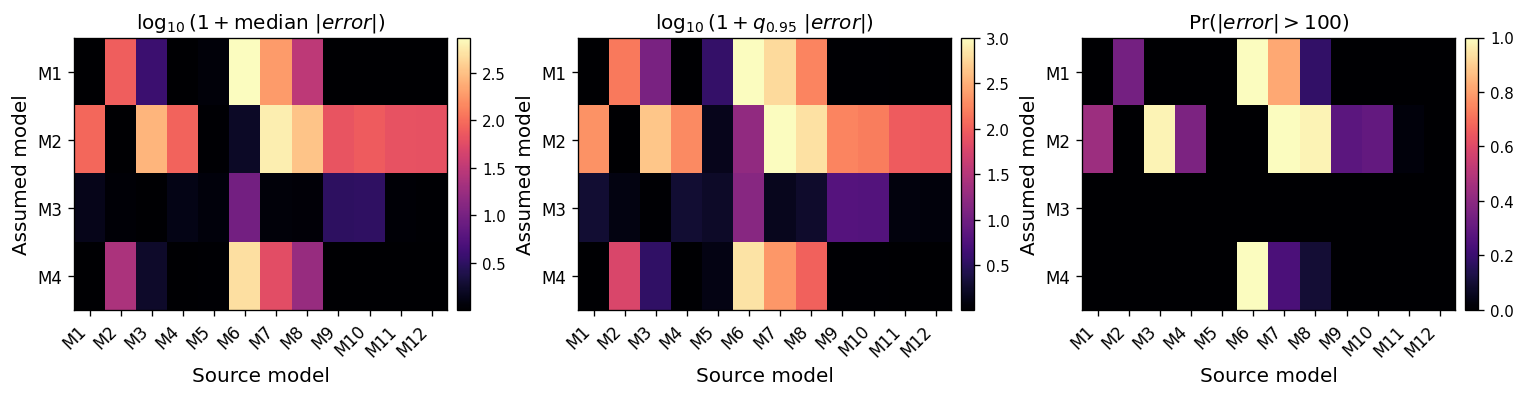

In [4]:
fig_heatmap, axes_heatmap, logml_error_summary = plot_logml_error_heatmaps(logml_df)
logml_error_summary.head()


## Option 2: split the original scatter plot into 4 x 4 panels

This keeps the original point-level diagnostic, but splits the 12 source models into three thesis-width figures.


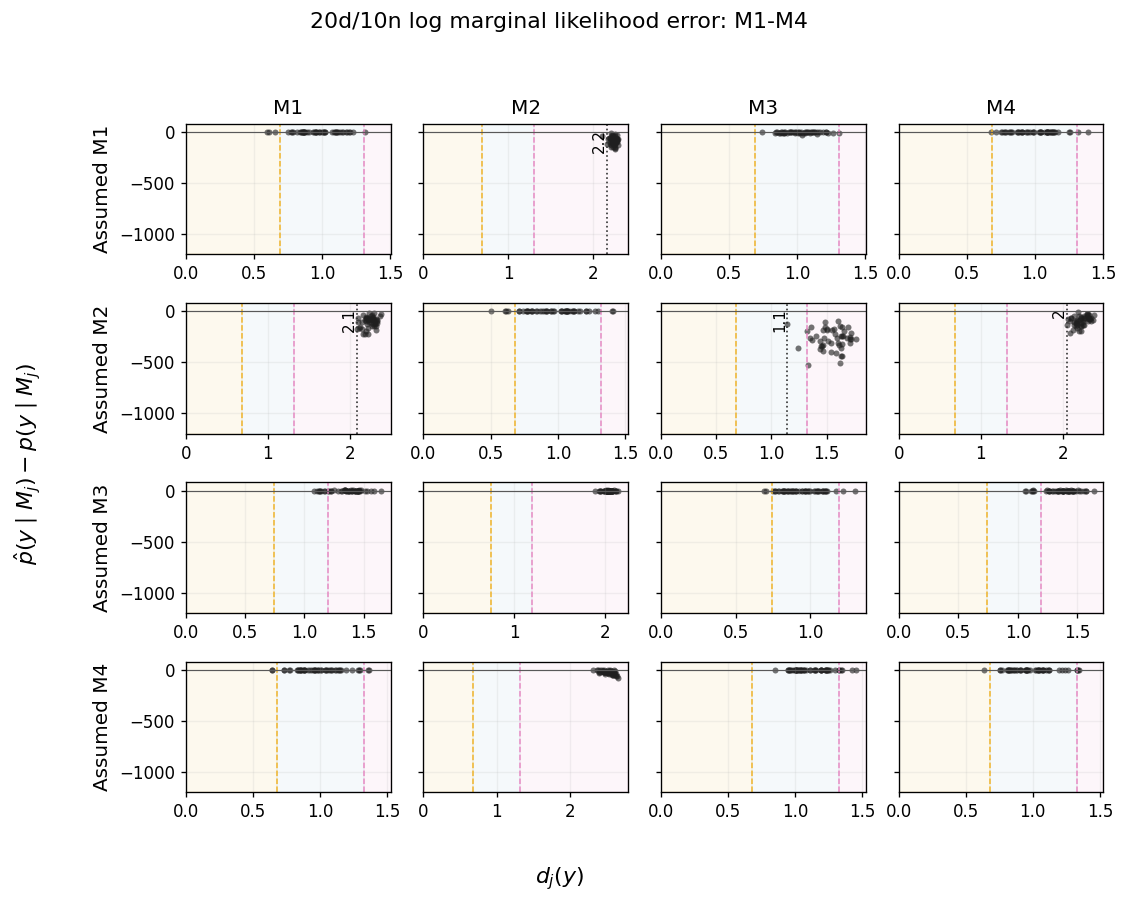

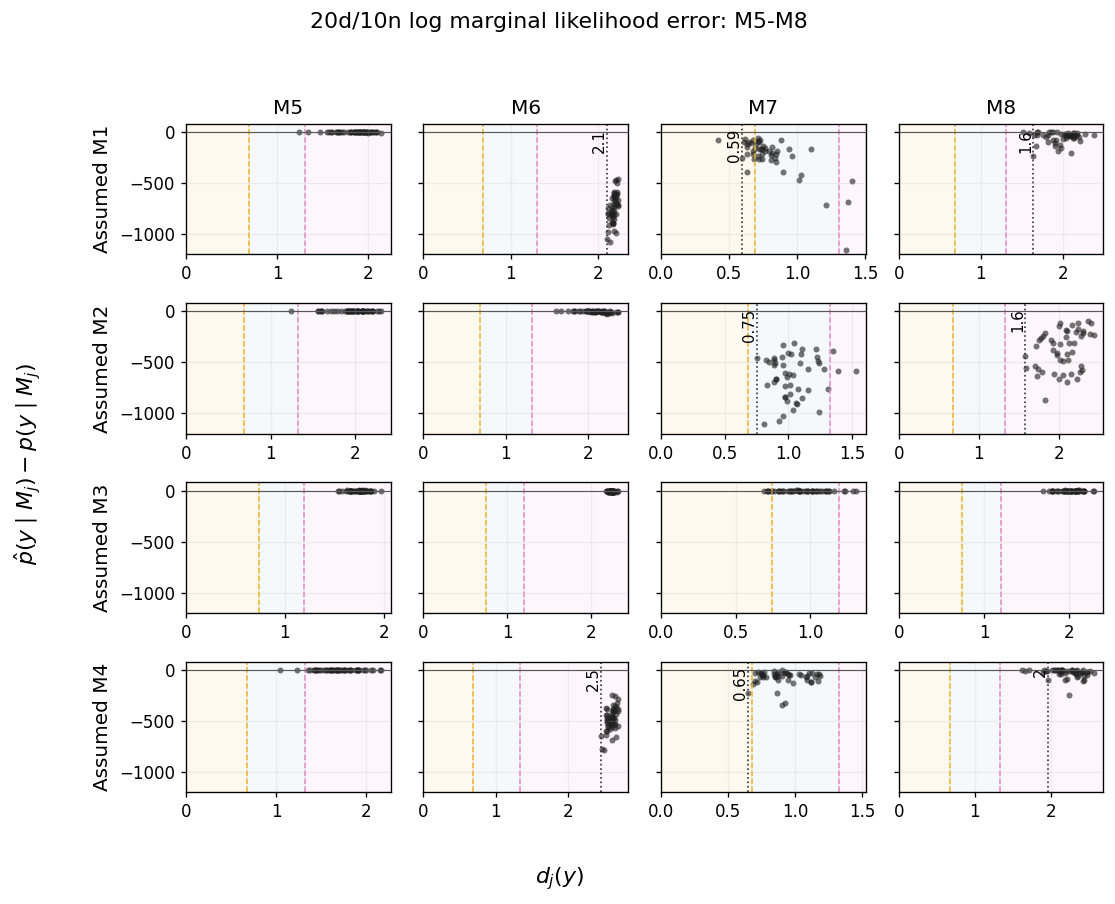

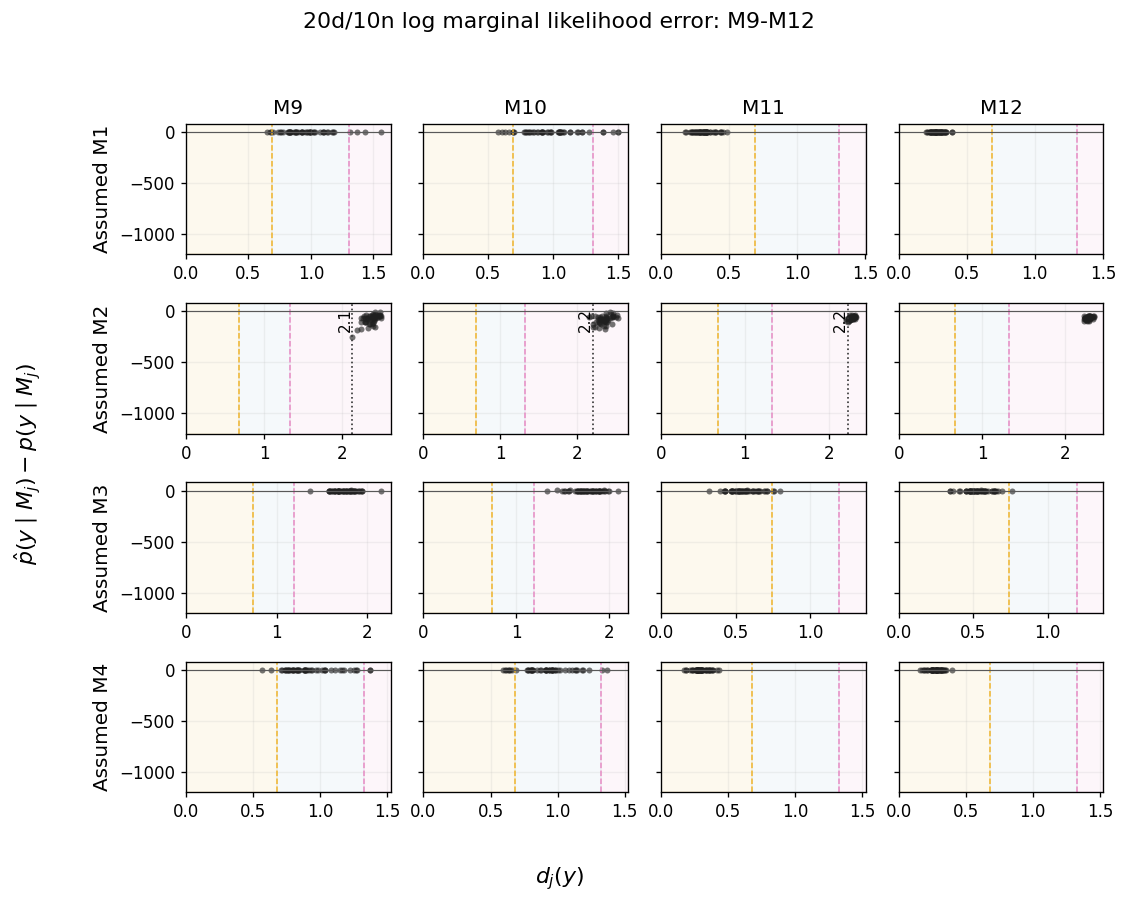

In [5]:
source_groups = [
    ("m1", "m2", "m3", "m4"),
    ("m5", "m6", "m7", "m8"),
    ("m9", "m10", "m11", "m12"),
]

split_figures = []
for i, group in enumerate(source_groups, start=1):
    fig, axes = plot_logml_scatter_grid(
        logml_df,
        sources=group,
        title=f"20d/10n log marginal likelihood error: {group[0].upper()}-{group[-1].upper()}",
        filename=f"logml_error_scatter_split_{i}_{group[0]}_{group[-1]}.png",
        x_min=0.0,
        y_limits=(-1200, 80),
    )
    split_figures.append(fig)


## Option 3: representative source models only

This is a smaller 4 x 4 scatter plot. Change `REPRESENTATIVE_SOURCES` in the first code cell if you want different source models.


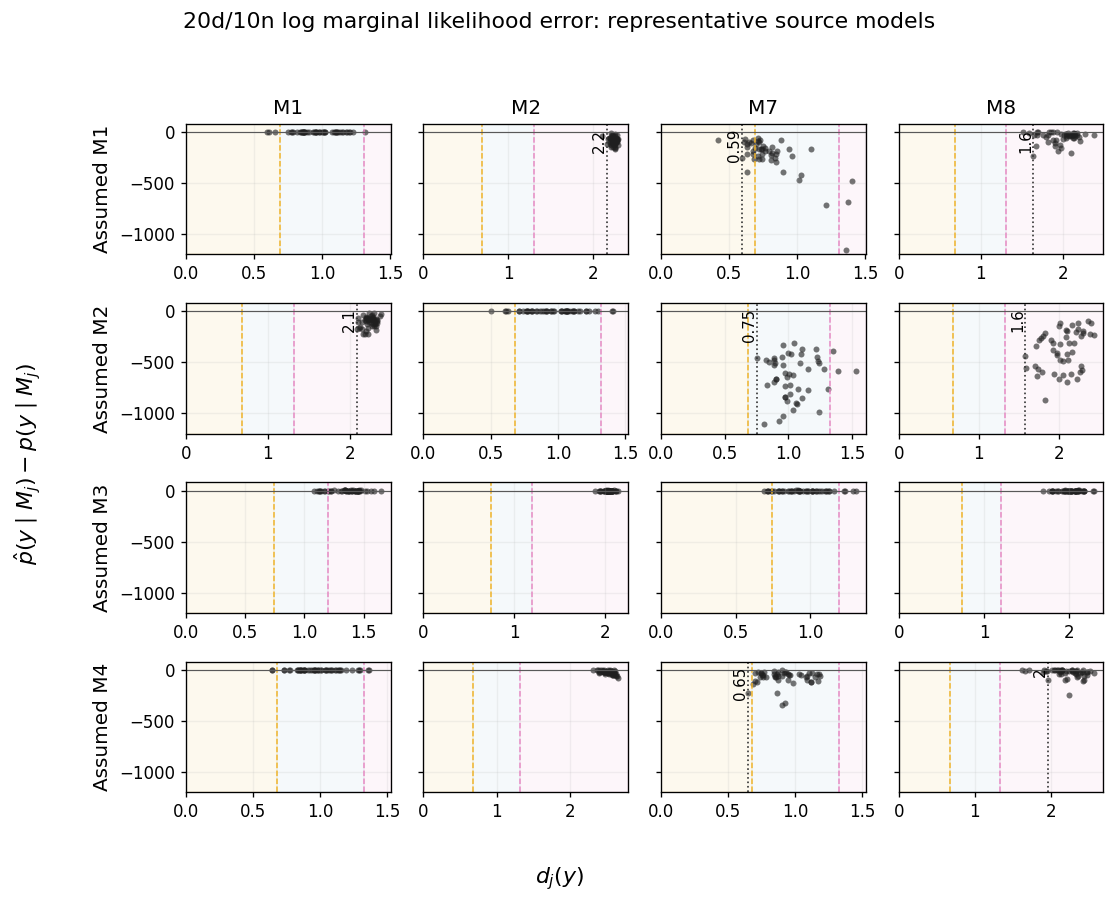

In [6]:
fig_rep, axes_rep = plot_logml_scatter_grid(
    logml_df,
    sources=REPRESENTATIVE_SOURCES,
    title="20d/10n log marginal likelihood error: representative source models",
    filename="logml_error_scatter_representative_sources.png",
    x_min=0.0,
    y_limits=(-1200, 80),
)


## Option 4: zoomed representative source models

Same representative models, but with a tighter y-axis. This can make small errors visible, at the cost of clipping extreme failures.


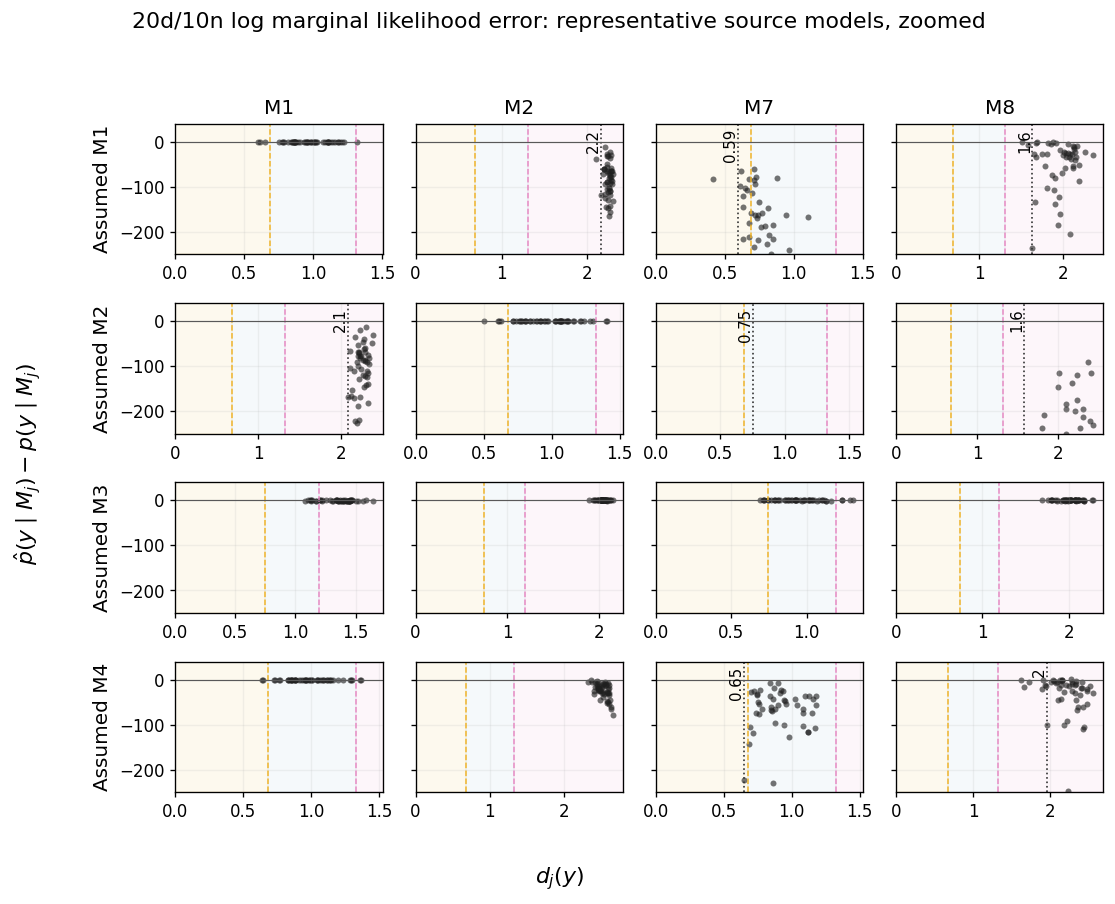

In [7]:
fig_rep_zoom, axes_rep_zoom = plot_logml_scatter_grid(
    logml_df,
    sources=REPRESENTATIVE_SOURCES,
    title="20d/10n log marginal likelihood error: representative source models, zoomed",
    filename="logml_error_scatter_representative_sources_zoomed.png",
    x_min=0.0,
    y_limits=(-250, 40),
)


In [8]:
print(f"Saved figures to: {FIGURE_DIR}")
for path in sorted(FIGURE_DIR.glob("*.png")):
    print(path.name)


Saved figures to: /Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/figures/ood_20d_10n_paper_fit
logml_error_heatmap_compact.png
logml_error_scatter_representative_sources.png
logml_error_scatter_representative_sources_zoomed.png
logml_error_scatter_split_1_m1_m4.png
logml_error_scatter_split_2_m5_m8.png
logml_error_scatter_split_3_m9_m12.png
